# PM10-Attributable Mortality in Morocco (2021)

Code accompanying Houdou et al., "Estimation of Mortality Attributable to Particulate Matter (PM10) Exposure in Morocco in 2021" (submitted to GeoHealth journal). Computes relative risk, attributable proportion, and attributable mortality cases among adults from CAMS PM10 reanalysis and WHO AirQ+ concentration-response functions.

In [1]:
#conda install numpy pandas xarray geopandas rasterstats matplotlib netcdf4 cartopy

import numpy as np
import pandas as pd
import xarray as xr
import rioxarray as rxr

import geopandas as gpd
import cartopy.crs as ccrs
from rasterstats import zonal_stats
from rasterio.enums import Resampling

import matplotlib.pyplot as plt

%run "Plot Functions - raster.ipynb"
%run "Plot_Functions_VectorData.ipynb"

### 1. Read the shapefile

In [2]:
# Read the shapefile using geopandas
shapefile_mar_reg = gpd.read_file("region maroc map/region_maroc.shp")
shapefile_mar_reg

,Province,AgroZone,geometry
0,SOUSS - MASSA,Defavorable Sud,"POLYGON ((-7.65616 30.90392, -7.63839 30.8862,..."
1,TANGER - TETOUAN -AL HOCEIMA,Defavorable Oriental,"POLYGON ((-5.34205 35.91004, -5.33174 35.90412..."
2,GUOLMIM - OUED NOUN,Saharienne,"POLYGON ((-9.29087 29.29466, -9.27126 29.29166..."
3,BNI MLLAL - KHNIFRA,Montagne,"POLYGON ((-5.69805 33.38248, -5.68574 33.37952..."
4,RABAT - SALE - KINITRA,Favorable,"POLYGON ((-6.19428 34.98783, -6.16995 34.98616..."
5,L'AYOUN - SAQIA,Saharienne,"POLYGON ((-11.731 28.03057, -11.7108 28.00123,..."
6,FES - MEKNES,Defavorable Oriental,"POLYGON ((-3.75701 34.87443, -3.74916 34.86844..."
7,CASABLANCA - SETTAT,Favorable,"POLYGON ((-7.38472 33.62491, -7.38422 33.61523..."
8,MARAKECH - SAFI,Defavorable Sud,"POLYGON ((-7.76231 32.65072, -7.75032 32.64935..."
9,REG ORIENTAL,Defavorable Oriental,"MULTIPOLYGON (((-3.43989 34.26467, -3.45446 34..."


In [3]:
shapefile_mar_reg.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [4]:
# Compute Centroids for Label Placement
shapefile_mar_reg['centroid'] = shapefile_mar_reg.geometry.centroid
shapefile_mar_reg

/scratch/ahoudou/job_54560743/ipykernel_1374821/4123303485.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  shapefile_mar_reg['centroid'] = shapefile_mar_reg.geometry.centroid


,Province,AgroZone,geometry,centroid
0,SOUSS - MASSA,Defavorable Sud,"POLYGON ((-7.65616 30.90392, -7.63839 30.8862,...",POINT (-8.42312 29.86374)
1,TANGER - TETOUAN -AL HOCEIMA,Defavorable Oriental,"POLYGON ((-5.34205 35.91004, -5.33174 35.90412...",POINT (-5.11925 35.17651)
2,GUOLMIM - OUED NOUN,Saharienne,"POLYGON ((-9.29087 29.29466, -9.27126 29.29166...",POINT (-9.9487 28.21642)
3,BNI MLLAL - KHNIFRA,Montagne,"POLYGON ((-5.69805 33.38248, -5.68574 33.37952...",POINT (-6.26855 32.46084)
4,RABAT - SALE - KINITRA,Favorable,"POLYGON ((-6.19428 34.98783, -6.16995 34.98616...",POINT (-6.25378 34.02036)
5,L'AYOUN - SAQIA,Saharienne,"POLYGON ((-11.731 28.03057, -11.7108 28.00123,...",POINT (-12.06637 26.33651)
6,FES - MEKNES,Defavorable Oriental,"POLYGON ((-3.75701 34.87443, -3.74916 34.86844...",POINT (-4.41322 33.78387)
7,CASABLANCA - SETTAT,Favorable,"POLYGON ((-7.38472 33.62491, -7.38422 33.61523...",POINT (-7.83074 32.94517)
8,MARAKECH - SAFI,Defavorable Sud,"POLYGON ((-7.76231 32.65072, -7.75032 32.64935...",POINT (-8.41696 31.70746)
9,REG ORIENTAL,Defavorable Oriental,"MULTIPOLYGON (((-3.43989 34.26467, -3.45446 34...",POINT (-2.5872 33.49219)


### 2. Read the PM10 data

In [5]:
# Read reanalysis PM10 data
Reanalysis_PM10_2021_2024 = xr.open_dataset('data/pm10/Reanalysis_PM10_2021_2024.nc')
Reanalysis_PM10_2021_2024

<xarray.Dataset> Size: 24MB
Dimensions:     (valid_time: 11688, latitude: 22, longitude: 23)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 94kB 2021-01-01 ... 2024-12-31T21...
  * latitude    (latitude) float64 176B 36.21 35.46 34.71 ... 21.96 21.21 20.46
  * longitude   (longitude) float64 184B -17.49 -16.74 -15.99 ... -1.74 -0.99
Data variables:
    pm10        (valid_time, latitude, longitude) float32 24MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-05-29T11:40 GRIB to CDM+CF via cfgrib-0.9.1...

In [6]:
print(Reanalysis_PM10_2021_2024.rio.crs)

None


In [7]:
# Select data for 2021 and write CRS
C_2021 = Reanalysis_PM10_2021_2024.sel(valid_time=Reanalysis_PM10_2021_2024['valid_time'].dt.year == 2021).pm10.mean(axis=0)*1000000000
C_2021 = C_2021.rio.write_crs("EPSG:4326")
print(C_2021.rio.crs)
C_2021

EPSG:4326


<xarray.DataArray 'pm10' (latitude: 22, longitude: 23)> Size: 2kB
array([[ 13.906241 ,  13.917162 ,  13.998509 ,  14.166729 ,  14.408917 ,
         14.663538 ,  14.955561 ,  15.148533 ,  15.352406 ,  15.688844 ,
         15.882877 ,  14.778948 ,  14.73275  ,  14.75275  ,  15.496836 ,
         17.37079  ,  19.855944 ,  19.484446 ,  18.538061 ,  18.331646 ,
         19.079798 ,  19.8828   ,  24.05159  ],
       [ 13.764178 ,  13.869795 ,  13.985304 ,  14.162083 ,  14.423934 ,
         14.7323675,  15.037126 ,  15.299138 ,  15.428608 ,  15.62087  ,
         15.8156595,  15.638584 ,  15.421248 ,  15.621778 ,  16.13204  ,
         23.028666 ,  25.907604 ,  21.259798 ,  19.44069  ,  19.715307 ,
         20.706003 ,  23.874428 ,  31.430893 ],
       [ 13.819974 ,  13.959843 ,  14.156488 ,  14.3649   ,  14.665593 ,
         15.024755 ,  15.372415 ,  15.575486 ,  15.511596 ,  15.628542 ,
         15.638247 ,  15.490807 ,  15.8319435,  16.172104 ,  28.320509 ,
         36.028217 ,  33.018284 ,  28.190643 ,  23.581854 ,  24.032764 ,
         26.626015 ,  29.579086 ,  35.496216 ],
       [ 13.733348 ,  13.863617 ,  14.085413 ,  14.495257 ,  14.88421  ,
         15.386451 ,  15.710834 ,  15.768985 ,  15.714653 ,  15.712688 ,
         15.729088 ,  15.705057 ,  17.079206 ,  32.44387  ,  47.03771  ,
         44.37661  ,  38.252    ,  31.901958 ,  27.07836  ,  31.428844 ,
         34.336384 ,  36.892258 ,  43.92273  ],
...
       [ 35.450485 ,  46.28811  , 115.27561  , 142.59216  , 138.46696  ,
        134.287    , 123.95834  , 117.77295  , 113.32185  , 111.325264 ,
        110.23998  , 106.543945 , 103.569626 ,  99.42854  ,  97.43339  ,
         96.37001  ,  96.544785 ,  98.21202  ,  99.73527  , 102.214386 ,
        104.3854   , 104.56366  , 103.89238  ],
       [ 41.62538  ,  91.47     , 144.21446  , 152.29097  , 146.39546  ,
        135.71138  , 124.16136  , 112.76828  , 107.72847  , 106.92582  ,
        106.30736  , 105.865234 , 103.0417   , 100.80277  ,  99.00269  ,
         98.46393  ,  98.647095 ,  99.589226 , 100.72833  , 102.865486 ,
        105.36406  , 107.07869  , 106.807144 ],
       [ 50.71814  , 107.04305  , 171.55258  , 181.43723  , 165.0584   ,
        150.23485  , 123.313416 , 118.21616  , 123.34664  , 123.22397  ,
        120.07728  , 119.15542  , 115.642685 , 113.26729  , 112.10098  ,
        111.71671  , 112.80234  , 113.98084  , 115.37064  , 117.236755 ,
        118.715065 , 120.135086 , 119.2809   ],
       [ 59.936546 , 101.4886   , 187.04369  , 209.41457  , 189.39809  ,
        164.67276  , 143.64421  , 153.80559  , 159.95673  , 154.28806  ,
        149.6271   , 142.26237  , 138.49786  , 135.16922  , 133.98083  ,
        133.18295  , 133.73717  , 133.77748  , 135.06258  , 135.7229   ,
        136.44234  , 131.69957  , 129.19356  ]], dtype=float32)
Coordinates:
  * latitude     (latitude) float64 176B 36.21 35.46 34.71 ... 21.96 21.21 20.46
  * longitude    (longitude) float64 184B -17.49 -16.74 -15.99 ... -1.74 -0.99
    spatial_ref  int64 8B 0
Attributes: (12/33)
    GRIB_paramId:                             210074
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      506
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_units:                               kg m**-3
    long_name:                                Particulate matter d <= 10 um
    units:                                    kg m**-3
    standard_name:                            mass_concentration_of_pm10_ambi...
    GRIB_number:                              0
    GRIB_surface:                             0.0

### 3. Clip PM10 to the Moroccan boundaries

In [8]:
# Clip
C_2021_cliped = C_2021.rio.clip(shapefile_mar_reg.geometry, shapefile_mar_reg.crs, drop=False, all_touched=True) 
C_2021_cliped

<xarray.DataArray 'pm10' (latitude: 22, longitude: 23)> Size: 2kB
array([[       nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan,
               nan,  19.855944,        nan,        nan,        nan,
               nan,        nan,        nan],
       [       nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan,
         23.028666,  25.907604,  21.259798,  19.44069 ,  19.715307,
         20.706003,        nan,        nan],
       [       nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan,
         36.028217,  33.018284,  28.190643,  23.581854,  24.032764,
         26.626015,  29.579086,        nan],
       [       nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,  32.44387 ,  47.03771 ,
         44.37661 ,  38.252   ,  31.901958,  27.07836 ,  31.428844,
         34.336384,  36.892258,        nan],
...
       [       nan,  46.28811 , 115.27561 , 142.59216 , 138.46696 ,
        134.287   , 123.95834 ,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan],
       [       nan,  91.47    , 144.21446 , 152.29097 , 146.39546 ,
        135.71138 , 124.16136 ,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan],
       [ 50.71814 , 107.04305 , 171.55258 , 181.43723 , 165.0584  ,
        150.23485 , 123.313416,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan],
       [ 59.936546, 101.4886  ,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan]], dtype=float32)
Coordinates:
  * latitude     (latitude) float64 176B 36.21 35.46 34.71 ... 21.96 21.21 20.46
  * longitude    (longitude) float64 184B -17.49 -16.74 -15.99 ... -1.74 -0.99
    spatial_ref  int64 8B 0
Attributes: (12/33)
    GRIB_paramId:                             210074
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      506
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_units:                               kg m**-3
    long_name:                                Particulate matter d <= 10 um
    units:                                    kg m**-3
    standard_name:                            mass_concentration_of_pm10_ambi...
    GRIB_number:                              0
    GRIB_surface:                             0.0

In [9]:
C_2021.rio.to_raster(f"data/pm10/pm10_raster_2021.tif")
list_dict_regions_stats = zonal_stats(shapefile_mar_reg, f"data/pm10/pm10_raster_2021.tif", stats=['mean'])
shapefile_mar_reg["PM10_mean_2021"] = [dict_region['mean'] for dict_region in list_dict_regions_stats]

/home/ahoudou/miniforge3/envs/pm10_mar/lib/python3.12/site-packages/rasterstats/io.py:437: NodataWarning: Setting nodata to -999; specify nodata explicitly
  warnings.warn(


In [10]:
shapefile_mar_reg

,Province,AgroZone,geometry,centroid,PM10_mean_2021
0,SOUSS - MASSA,Defavorable Sud,"POLYGON ((-7.65616 30.90392, -7.63839 30.8862,...",POINT (-8.42312 29.86374),28.220808
1,TANGER - TETOUAN -AL HOCEIMA,Defavorable Oriental,"POLYGON ((-5.34205 35.91004, -5.33174 35.90412...",POINT (-5.11925 35.17651),25.907604
2,GUOLMIM - OUED NOUN,Saharienne,"POLYGON ((-9.29087 29.29466, -9.27126 29.29166...",POINT (-9.9487 28.21642),40.505284
3,BNI MLLAL - KHNIFRA,Montagne,"POLYGON ((-5.69805 33.38248, -5.68574 33.37952...",POINT (-6.26855 32.46084),32.679605
4,RABAT - SALE - KINITRA,Favorable,"POLYGON ((-6.19428 34.98783, -6.16995 34.98616...",POINT (-6.25378 34.02036),37.807704
5,L'AYOUN - SAQIA,Saharienne,"POLYGON ((-11.731 28.03057, -11.7108 28.00123,...",POINT (-12.06637 26.33651),83.965121
6,FES - MEKNES,Defavorable Oriental,"POLYGON ((-3.75701 34.87443, -3.74916 34.86844...",POINT (-4.41322 33.78387),30.237225
7,CASABLANCA - SETTAT,Favorable,"POLYGON ((-7.38472 33.62491, -7.38422 33.61523...",POINT (-7.83074 32.94517),33.540054
8,MARAKECH - SAFI,Defavorable Sud,"POLYGON ((-7.76231 32.65072, -7.75032 32.64935...",POINT (-8.41696 31.70746),25.833934
9,REG ORIENTAL,Defavorable Oriental,"MULTIPOLYGON (((-3.43989 34.26467, -3.45446 34...",POINT (-2.5872 33.49219),36.017048


### 4. Plot PM10 at grid cell and regional level

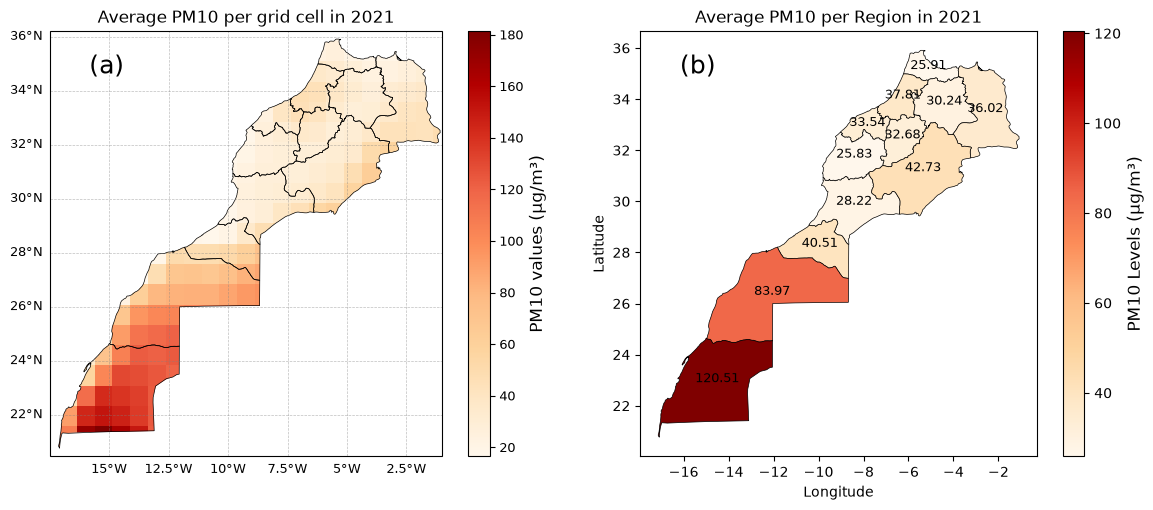

In [11]:
# Define the Albers Equal Area Conic projection parameters for the region
projection = ccrs.PlateCarree()

fig = plt.figure(figsize=(12, 5))
gs = fig.add_gridspec(nrows=1, ncols=2)

axs = [[None]*2 for _ in range(1)]
axs[0][0] = fig.add_subplot(gs[0, 0], projection=projection)  # Cartopy GeoAxes
axs[0][1] = fig.add_subplot(gs[0, 1])                          # plain Axes, no projection

# Define the common range for the color scale
vmin, vmax = None, None

# Define latitude and longitude
latitude = C_2021_cliped.latitude.values
longitude = C_2021_cliped.longitude.values

ax = axs[0][0]
c = Plot_Map_pcolormesh(data=C_2021_cliped, latitude=latitude, longitude=longitude, projection=projection, Title='Average PM10 per grid cell in 2021', label = 'PM10 values (µg/m³)', cmap="OrRd", ax=ax, vmin=vmin, vmax=vmax, shapefile=shapefile_mar_reg, coastlines=False, common_colorbar=False, colorbar_ticks_to_int=False)
clip_artist_to_shape(c, ax, shapefile_mar_reg.geometry)
ax.text(0.1, 0.9, '(a)', transform=ax.transAxes, fontsize=18)

ax = axs[0][1]
Plot_Shapefile_ContinueData(shapefile_mar_reg, column='PM10_mean_2021', cmap='OrRd', title='Average PM10 per Region in 2021', label="PM10 Levels (µg/m³)", txt_labels_size=9, add_txt_labels=True, txt_labels_round=2, ax=ax)
ax.text(0.1, 0.9, '(b)', transform=ax.transAxes, fontsize=18)

# Adjust subplot layout
plt.tight_layout()

# Show the map
plt.show() 

# Save the plot to a file (e.g., in PNG format)
fig.savefig('Figures_PM10/Figure 2.png', bbox_inches="tight", dpi=500)

### 5. Calculating RR and AP per grid cell

In [12]:
# WHO settings

beta = 0.003922071315328133
beta_lower = 0.002955880224154443
beta_upper = 0.005826890812397583
Cs = [40, 20, 15]

#C0 = 40 # Morocco
#C0 = 20 #Old WHO
#C0 = 15 # New WHO

In [13]:
RRs, RRs_lower, RRs_upper = [], [], []
APs, APs_lower, APs_upper = [], [], []
for C0 in Cs:
    
    # Relative risks
    RR = np.exp(beta*(C_2021_cliped - C0))
    RR_lower = np.exp(beta_lower*(C_2021_cliped - C0))
    RR_upper = np.exp(beta_upper*(C_2021_cliped - C0))

    # Attributable Proportion
    AP = (RR-1)/RR*100
    AP_lower = (RR_lower-1)/RR*100
    AP_upper = (RR_upper-1)/RR*100
    
    # replace negative values with 0
    AP = np.where(AP < 0, 0, AP)
    AP_lower = np.where(AP_lower < 0, 0, AP_lower)
    AP_upper = np.where(AP_upper < 0, 0, AP_upper)

    RRs.append(RR)
    RRs_lower.append(RR_lower)
    RRs_upper.append(RR_upper)
    
    APs.append(AP)
    APs_lower.append(AP_lower)
    APs_upper.append(AP_upper)

### 6. Plotting RR and AP per grid cell

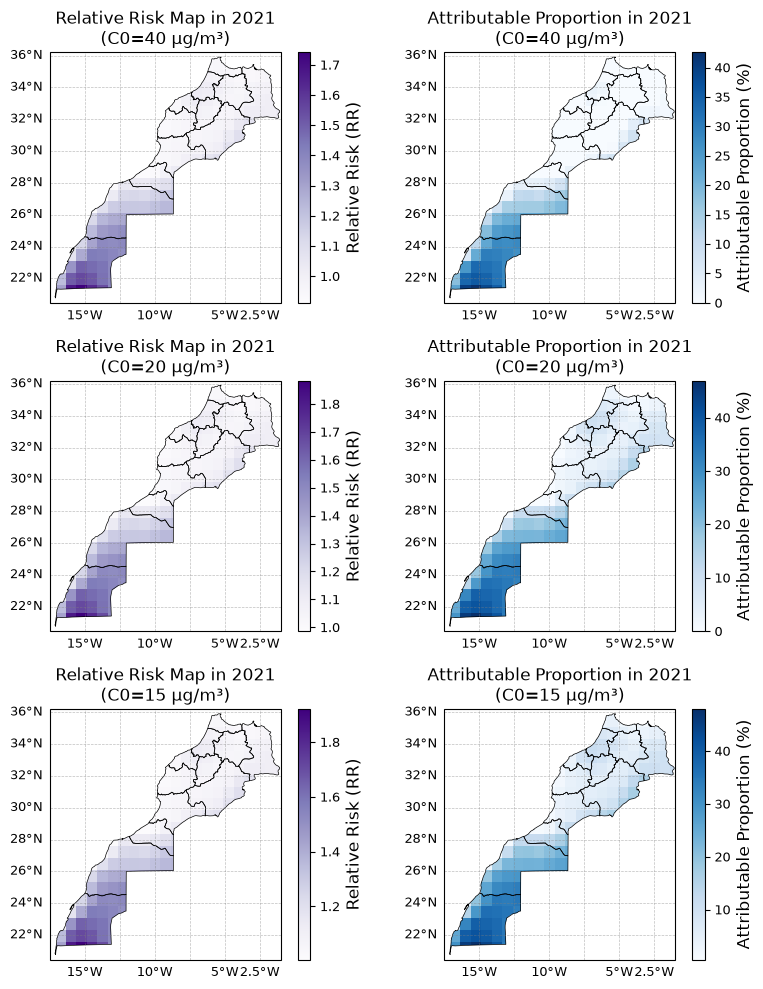

In [14]:
# Define the Albers Equal Area Conic projection parameters for the region
projection = ccrs.PlateCarree()

# Create a map projection
fig, axs = plt.subplots(nrows=3, ncols=2, subplot_kw={'projection': projection}, figsize=(8, 10))

# Define the common range for the color scale
vmin, vmax = None, None

# Define latitude and longitude
latitude = C_2021_cliped.latitude.values
longitude = C_2021_cliped.longitude.values

for i in range(3):
    
    ax = axs[i, 0]
    c = Plot_Map_pcolormesh(data=RRs[i], latitude=latitude, longitude=longitude, projection=projection, Title=f'Relative Risk Map in 2021\n(C0={Cs[i]} µg/m³)', cmap="Purples", label = 'Relative Risk (RR)', ax=ax, vmin=vmin, vmax=vmax, shapefile=shapefile_mar_reg, coastlines=False, common_colorbar=False, colorbar_ticks_to_int=False)
    clip_artist_to_shape(c, ax, shapefile_mar_reg.geometry)
    
    ax = axs[i, 1]
    c = Plot_Map_pcolormesh(data=APs[i], latitude=latitude, longitude=longitude, projection=projection, Title=f'Attributable Proportion in 2021\n(C0={Cs[i]} µg/m³)', cmap="Blues", label = 'Attributable Proportion (%)', ax=ax, vmin=vmin, vmax=vmax, shapefile=shapefile_mar_reg, coastlines=False, common_colorbar=False, colorbar_ticks_to_int=False)
    clip_artist_to_shape(c, ax, shapefile_mar_reg.geometry)

# Adjust subplot layout
plt.tight_layout()

# Show the map
plt.show() 

In [15]:
print(RRs[0].max().values)
print(RRs[1].max().values)
print(RRs[2].max().values)

1.7414653
1.8835689
1.920871


In [16]:
print(np.nanmax(APs[0]))
print(np.nanmax(APs[1]))
print(np.nanmax(APs[2]))

42.577095
46.909294
47.940285


In [17]:
RRs_bellow_list = []
for i in range(3):
    RRs_bellow_list.append(np.where(RRs[i].values>1, np.nan, RRs[i].values))

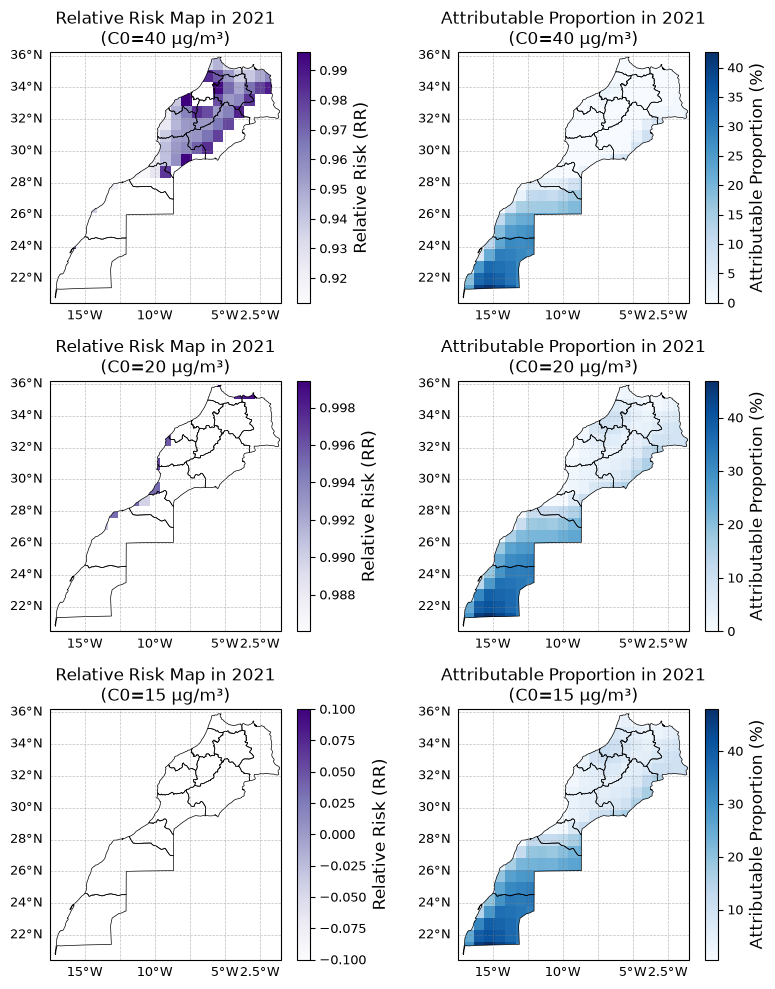

In [18]:
# Define the Albers Equal Area Conic projection parameters for the region
projection = ccrs.PlateCarree()

# Create a map projection
fig, axs = plt.subplots(nrows=3, ncols=2, subplot_kw={'projection': projection}, figsize=(8, 10))

# Define the common range for the color scale
vmin, vmax = None, None

# Define latitude and longitude
latitude = C_2021_cliped.latitude.values
longitude = C_2021_cliped.longitude.values

for i in range(3):
    
    ax = axs[i, 0]
    c = Plot_Map_pcolormesh(data=RRs_bellow_list[i], latitude=latitude, longitude=longitude, projection=projection, Title=f'Relative Risk Map in 2021\n(C0={Cs[i]} µg/m³)', cmap="Purples", label = 'Relative Risk (RR)', ax=ax, vmin=vmin, vmax=vmax, shapefile=shapefile_mar_reg, coastlines=False, common_colorbar=False, colorbar_ticks_to_int=False)
    clip_artist_to_shape(c, ax, shapefile_mar_reg.geometry)
    
    ax = axs[i, 1]
    c = Plot_Map_pcolormesh(data=APs[i], latitude=latitude, longitude=longitude, projection=projection, Title=f'Attributable Proportion in 2021\n(C0={Cs[i]} µg/m³)', cmap="Blues", label = 'Attributable Proportion (%)', ax=ax, vmin=vmin, vmax=vmax, shapefile=shapefile_mar_reg, coastlines=False, common_colorbar=False, colorbar_ticks_to_int=False)
    clip_artist_to_shape(c, ax, shapefile_mar_reg.geometry)

# Adjust subplot layout
plt.tight_layout()

# Show the map
plt.show() 

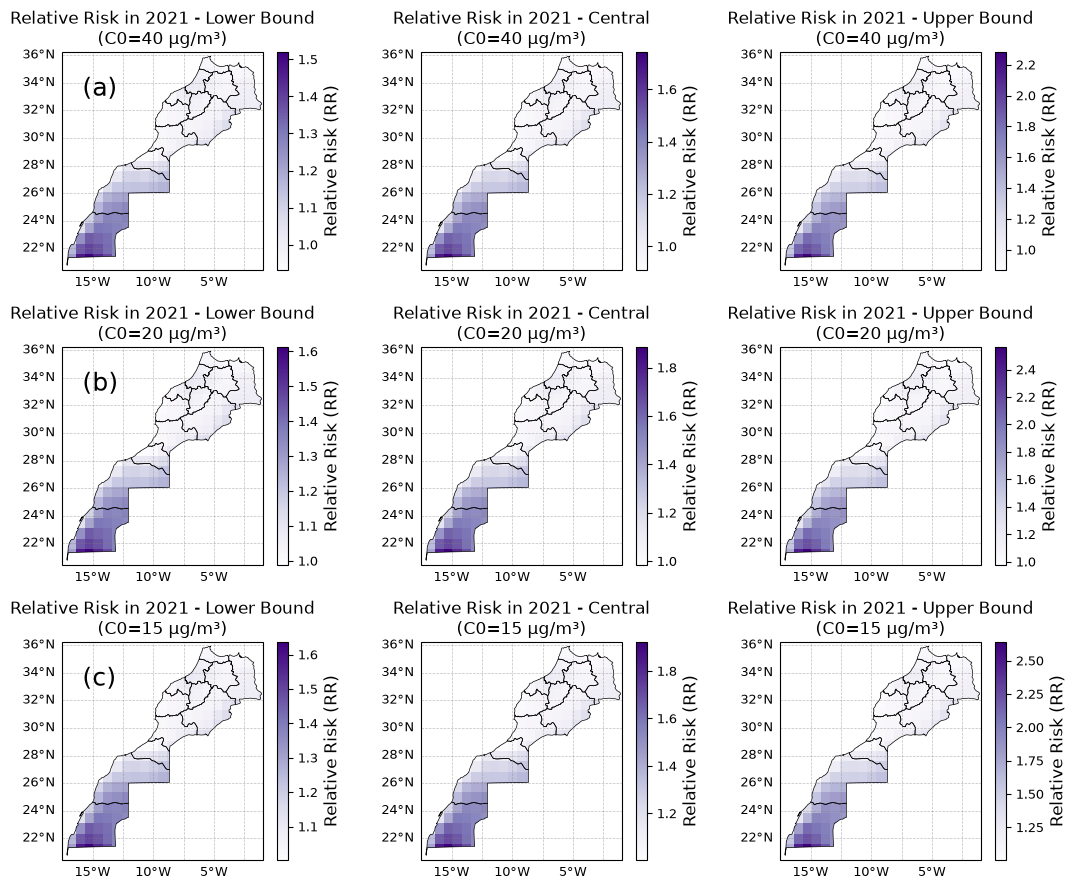

In [19]:
# Define the Albers Equal Area Conic projection parameters for the region
projection = ccrs.PlateCarree()

# Create a map projection
fig, axs = plt.subplots(nrows=3, ncols=3, subplot_kw={'projection': projection}, figsize=(11, 9))

# Define latitude and longitude
latitude = C_2021_cliped.latitude
longitude = C_2021_cliped.longitude

# Define the common range for the color scale
vmin, vmax = None, None

letters = ['(a)', '(b)', '(c)']
for i in range(3):
    
    ax = axs[i, 0]
    c = Plot_Map_pcolormesh(data=RRs_lower[i], latitude=latitude, longitude=longitude, projection=projection, Title=f'Relative Risk in 2021 - Lower Bound\n(C0={Cs[i]} µg/m³)', cmap="Purples", label = 'Relative Risk (RR)', ax=ax, vmin=vmin, vmax=vmax, shapefile=shapefile_mar_reg, coastlines=False, common_colorbar=False, colorbar_ticks_to_int=False)
    clip_artist_to_shape(c, ax, shapefile_mar_reg.geometry)
    ax.text(0.1, 0.8, letters[i], transform=ax.transAxes, fontsize=18)

    ax = axs[i, 1]
    c = Plot_Map_pcolormesh(data=RRs[i], latitude=latitude, longitude=longitude, projection=projection, Title=f'Relative Risk in 2021 - Central\n(C0={Cs[i]} µg/m³)', cmap="Purples", label = 'Relative Risk (RR)', ax=ax, vmin=vmin, vmax=vmax, shapefile=shapefile_mar_reg, coastlines=False, common_colorbar=False, colorbar_ticks_to_int=False)
    clip_artist_to_shape(c, ax, shapefile_mar_reg.geometry)

    ax = axs[i, 2]
    c = Plot_Map_pcolormesh(data=RRs_upper[i], latitude=latitude, longitude=longitude, projection=projection, Title=f'Relative Risk in 2021 - Upper Bound\n(C0={Cs[i]} µg/m³)', cmap="Purples", label = 'Relative Risk (RR)', ax=ax, vmin=vmin, vmax=vmax, shapefile=shapefile_mar_reg, coastlines=False, common_colorbar=False, colorbar_ticks_to_int=False)
    clip_artist_to_shape(c, ax, shapefile_mar_reg.geometry)
    

# Adjust subplot layout
plt.tight_layout()

# Show the map
plt.show() 

# Save the plot to a file (e.g., in PNG format)
fig.savefig('Figures_PM10/Figure S1.png', bbox_inches="tight", dpi=500)

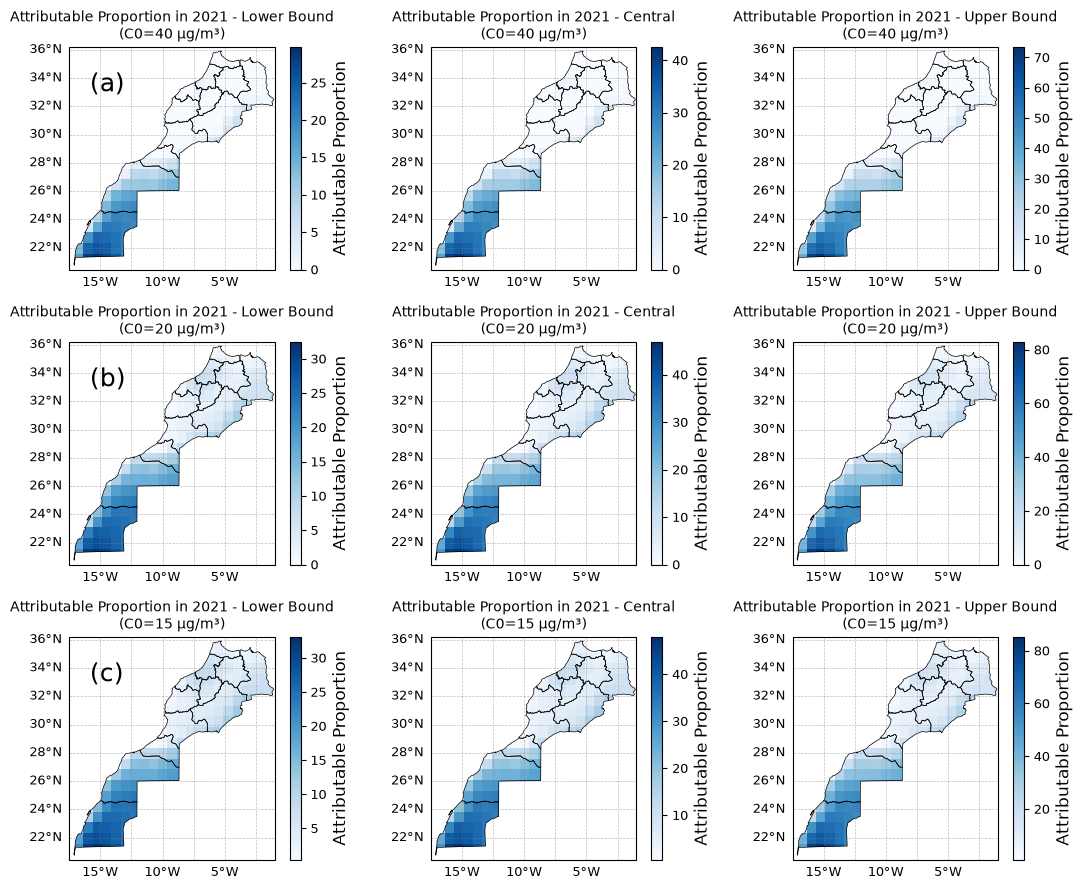

In [21]:
# Define the Albers Equal Area Conic projection parameters for the region
projection = ccrs.PlateCarree()

# Create a map projection
fig, axs = plt.subplots(nrows=3, ncols=3, subplot_kw={'projection': projection}, figsize=(11, 9))

# Define latitude and longitude
latitude = C_2021_cliped.latitude
longitude = C_2021_cliped.longitude

# Define the common range for the color scale
vmin, vmax = None, None

letters = ['(a)', '(b)', '(c)']
for i in range(3):
    
    ax = axs[i, 0]
    c = Plot_Map_pcolormesh(data=APs_lower[i], latitude=latitude, longitude=longitude, projection=projection, Title=f'Attributable Proportion in 2021 - Lower Bound\n(C0={Cs[i]} µg/m³)', fontsize_title=10, cmap="Blues", label = 'Attributable Proportion', ax=ax, vmin=vmin, vmax=vmax, shapefile=shapefile_mar_reg, coastlines=False, common_colorbar=False, colorbar_ticks_to_int=False)
    clip_artist_to_shape(c, ax, shapefile_mar_reg.geometry)
    ax.text(0.1, 0.8, letters[i], transform=ax.transAxes, fontsize=18)

    ax = axs[i, 1]
    c = Plot_Map_pcolormesh(data=APs[i], latitude=latitude, longitude=longitude, projection=projection, Title=f'Attributable Proportion in 2021 - Central\n(C0={Cs[i]} µg/m³)', fontsize_title=10, cmap="Blues", label = 'Attributable Proportion', ax=ax, vmin=vmin, vmax=vmax, shapefile=shapefile_mar_reg, coastlines=False, common_colorbar=False, colorbar_ticks_to_int=False)
    clip_artist_to_shape(c, ax, shapefile_mar_reg.geometry)

    ax = axs[i, 2]
    c = Plot_Map_pcolormesh(data=APs_upper[i], latitude=latitude, longitude=longitude, projection=projection, Title=f'Attributable Proportion in 2021 - Upper Bound\n(C0={Cs[i]} µg/m³)', fontsize_title=10, cmap="Blues", label = 'Attributable Proportion', ax=ax, vmin=vmin, vmax=vmax, shapefile=shapefile_mar_reg, coastlines=False, common_colorbar=False, colorbar_ticks_to_int=False)
    clip_artist_to_shape(c, ax, shapefile_mar_reg.geometry)
    

# Adjust subplot layout
plt.tight_layout()

# Show the map
plt.show() 

# Save the plot to a file (e.g., in PNG format)
fig.savefig('Figures_PM10/Figure S2.png', bbox_inches="tight", dpi=500)

### 7. Read WorldPop 2021 data

In [22]:
WorldPop_Morocco_2021 = xr.open_dataset('data/WorldPop_Morocco_2021.nc')
WorldPop_Morocco_2021 = WorldPop_Morocco_2021.rio.write_crs(C_2021_cliped.rio.crs)
WorldPop_Morocco_2021

<xarray.Dataset> Size: 28MB
Dimensions:                        (y: 1818, x: 1933)
Coordinates:
  * y                              (y) float64 15kB 35.92 35.91 ... 20.79 20.78
  * x                              (x) float64 15kB -17.1 -17.1 ... -1.004
    spatial_ref                    int64 8B 0
Data variables:
    __xarray_dataarray_variable__  (y, x) float64 28MB ...

In [23]:
print(WorldPop_Morocco_2021.__xarray_dataarray_variable__.min().values)
print(WorldPop_Morocco_2021.__xarray_dataarray_variable__.max().values)
print(WorldPop_Morocco_2021.__xarray_dataarray_variable__.sum().values)

0.0
19316.623046875
37328518.99679913


In [24]:
WorldPop_Morocco_2021.rio.crs

CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]')

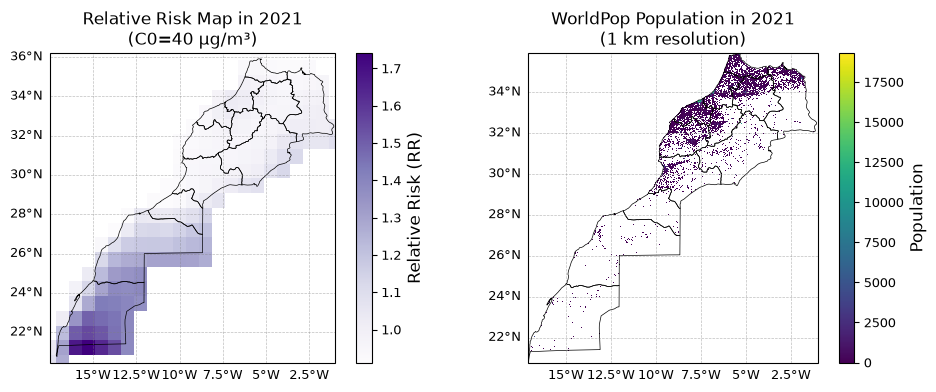

In [25]:
# Define the Albers Equal Area Conic projection parameters for the region
projection = ccrs.PlateCarree()

# Create a map projection
fig, axs = plt.subplots(nrows=1, ncols=2, subplot_kw={'projection': projection}, figsize=(10, 4))

# Define the common range for the color scale
vmin, vmax = None, None

latitude = RRs[0].latitude
longitude = RRs[0].longitude
ax = axs[0]
c = Plot_Map_pcolormesh(data=RRs[0], latitude=latitude, longitude=longitude, projection=projection, Title=f'Relative Risk Map in 2021\n(C0=40 µg/m³)', label = 'Relative Risk (RR)', cmap="Purples", ax=ax, vmin=vmin, vmax=vmax, shapefile=shapefile_mar_reg, coastlines=False, common_colorbar=False, colorbar_ticks_to_int=False)

latitude = WorldPop_Morocco_2021.y
longitude = WorldPop_Morocco_2021.x
ax = axs[1]
c = Plot_Map_pcolormesh(data=WorldPop_Morocco_2021.__xarray_dataarray_variable__, latitude=latitude, longitude=longitude, projection=projection, Title=f'WorldPop Population in 2021\n(1 km resolution)', label = 'Population', cmap="viridis", ax=ax, vmin=vmin, vmax=vmax, shapefile=shapefile_mar_reg, coastlines=False, common_colorbar=False, colorbar_ticks_to_int=False)


# Adjust subplot layout
plt.tight_layout()

# Show the map
plt.show() 

### 8. Regrid the WorldPop population from 1km to ~200m

- A boundary cell can be counted in full in both neighbouring regions, so the regional populations add up to more than the national total.

- To reduce the effect of counting a population cell in both neighbouring regions when clipping the population of cells at the boundary regions, we regridded the WorldPop population from 1km to 200m before clipping, assuming people are spread uniformly within a 1 km cell. This got an area-weighted count at the boundary with an error of 0.14%.

In [26]:
k = 5
WorldPop_Morocco_2021_finer_resolution = WorldPop_Morocco_2021.rio.reproject(
    WorldPop_Morocco_2021.rio.crs,
    shape=(WorldPop_Morocco_2021.sizes["y"] * k, WorldPop_Morocco_2021.sizes["x"] * k),
    resampling=Resampling.nearest) / k**2

WorldPop_Morocco_2021_finer_resolution = WorldPop_Morocco_2021_finer_resolution.fillna(0)
WorldPop_Morocco_2021_finer_resolution

<xarray.Dataset> Size: 703MB
Dimensions:                        (y: 9090, x: 9665)
Coordinates:
  * y                              (y) float64 73kB 35.92 35.92 ... 20.78 20.78
  * x                              (x) float64 77kB -17.11 -17.11 ... -1.001
    spatial_ref                    int64 8B 0
Data variables:
    __xarray_dataarray_variable__  (y, x) float64 703MB 0.0 0.0 0.0 ... 0.0 0.0

In [27]:
print(WorldPop_Morocco_2021_finer_resolution.__xarray_dataarray_variable__.min().values)
print(WorldPop_Morocco_2021_finer_resolution.__xarray_dataarray_variable__.max().values)
print(WorldPop_Morocco_2021_finer_resolution.__xarray_dataarray_variable__.sum().values)

0.0
772.664921875
37328518.99679913


### Compare the total population before and after clipping

In [28]:
# Removing coastal cells whose centres might be over sea in our coastline (outside every region).
WorldPop_Morocco_2021_clipped = WorldPop_Morocco_2021_finer_resolution.rio.clip(shapefile_mar_reg.geometry, shapefile_mar_reg.crs, drop=False, all_touched=True)

In [29]:
pop_tot = 0
for idx, row in shapefile_mar_reg.iterrows(): # loop over all Moroccan regions
    region_name = row['Province']
    region_geom = [row.geometry]

    # Clipping the population
    region_Pop  = WorldPop_Morocco_2021_clipped.rio.clip(region_geom, shapefile_mar_reg.crs, drop=False, all_touched=True)
    pop_tot += region_Pop.__xarray_dataarray_variable__.sum().values

In [34]:
tot_pop_national = WorldPop_Morocco_2021_clipped.__xarray_dataarray_variable__.sum().values
(pop_tot - tot_pop_national)/tot_pop_national*100

np.float64(0.14130578949042558)

In [37]:
# Comparing it with the HCP total population
(36512888.950956985 - 36313189)/36313189*100

0.5499377952098489

### 9. Read the Regional Population in 2021 from HCP 

In [35]:
pop = pd.read_excel('data/Population.xlsx', usecols=['Name', 'Pop_Adult_2021'])
pop = pop.iloc[0:12]
pop

,Name,Pop_Adult_2021
0,SOUSS - MASSA,1521070.222
1,TANGER - TETOUAN -AL HOCEIMA,1913288.752
2,GUOLMIM - OUED NOUN,232710.258
3,BNI MLLAL - KHNIFRA,1345604.096
4,RABAT - SALE - KINITRA,2570896.979
5,L'AYOUN - SAQIA,193365.480
6,FES - MEKNES,2296664.888
7,CASABLANCA - SETTAT,3938841.900
8,MARAKECH - SAFI,2384052.165
9,REG ORIENTAL,1316517.327


### 10. Read the Annual Mortality rate per 10,000 for each region in 2021 

In [37]:
M_rate = pd.read_excel('data/Mortality_Rate_MH_2021.xlsx', usecols=['Name', 'MR_Adult_2021 per 10,000'])
M_rate = M_rate.iloc[0:12]

### 11. Perform Spatial Aggregation

In [38]:
shapefile_mar_reg

,Province,AgroZone,geometry,centroid,PM10_mean_2021
0,SOUSS - MASSA,Defavorable Sud,"POLYGON ((-7.65616 30.90392, -7.63839 30.8862,...",POINT (-8.42312 29.86374),28.220808
1,TANGER - TETOUAN -AL HOCEIMA,Defavorable Oriental,"POLYGON ((-5.34205 35.91004, -5.33174 35.90412...",POINT (-5.11925 35.17651),25.907604
2,GUOLMIM - OUED NOUN,Saharienne,"POLYGON ((-9.29087 29.29466, -9.27126 29.29166...",POINT (-9.9487 28.21642),40.505284
3,BNI MLLAL - KHNIFRA,Montagne,"POLYGON ((-5.69805 33.38248, -5.68574 33.37952...",POINT (-6.26855 32.46084),32.679605
4,RABAT - SALE - KINITRA,Favorable,"POLYGON ((-6.19428 34.98783, -6.16995 34.98616...",POINT (-6.25378 34.02036),37.807704
5,L'AYOUN - SAQIA,Saharienne,"POLYGON ((-11.731 28.03057, -11.7108 28.00123,...",POINT (-12.06637 26.33651),83.965121
6,FES - MEKNES,Defavorable Oriental,"POLYGON ((-3.75701 34.87443, -3.74916 34.86844...",POINT (-4.41322 33.78387),30.237225
7,CASABLANCA - SETTAT,Favorable,"POLYGON ((-7.38472 33.62491, -7.38422 33.61523...",POINT (-7.83074 32.94517),33.540054
8,MARAKECH - SAFI,Defavorable Sud,"POLYGON ((-7.76231 32.65072, -7.75032 32.64935...",POINT (-8.41696 31.70746),25.833934
9,REG ORIENTAL,Defavorable Oriental,"MULTIPOLYGON (((-3.43989 34.26467, -3.45446 34...",POINT (-2.5872 33.49219),36.017048


In [39]:
# Clipping and Regridding the population (this cell may take up to 8:29)
region_Pop_regridded_list = []
for idx, row in shapefile_mar_reg.iterrows(): # loop over all Moroccan regions
    region_name = row['Province']
    region_geom = [row.geometry]
    print(f"Region: {region_name}")

    # Clipping the relative risks to its corresponding region
    region_RR = RRs[0].rio.clip(region_geom, shapefile_mar_reg.crs, drop=False, all_touched=True)

    # Clipping and Regridding the population
    region_Pop  = WorldPop_Morocco_2021_finer_resolution.rio.clip(region_geom, shapefile_mar_reg.crs, drop=False, all_touched=True)
    region_Pop = region_Pop.fillna(0)
    region_Pop_regridded = region_Pop.rio.reproject_match(region_RR, resampling=Resampling.sum) # 1km grid at the boundaries of the  70-80 km grid cell (area-weighted) # Resampling.sum computes a weighted sum of the source pixels (1km grid), with each 1 km cell weighted by how much of it overlaps the destination cell (70-80 km grid)

    region_Pop_regridded_list.append(region_Pop_regridded)

Region: SOUSS - MASSA
Region: TANGER - TETOUAN -AL HOCEIMA
Region: GUOLMIM - OUED NOUN
Region: BNI MLLAL - KHNIFRA
Region: RABAT - SALE - KINITRA
Region: L'AYOUN - SAQIA
Region: FES - MEKNES
Region: CASABLANCA - SETTAT
Region: MARAKECH - SAFI
Region: REG ORIENTAL
Region: DAKHLA - OUAD EDDAHAB
Region: DRAA - TAFILALT


In [40]:
shapefile_mar_reg_ = shapefile_mar_reg.copy()

In [41]:
for i in range(3):  # loop over the 3 guidelines (40, 20, 15)

    results_AP, results_AP_lower, results_AP_upper = [], [], []
    for idx, row in shapefile_mar_reg.iterrows(): # loop over all Moroccan regions
        region_geom = [row.geometry]

        # Clipping the relative risks to its corresponding region
        region_RR = RRs[i].rio.clip(region_geom, shapefile_mar_reg.crs, drop=False, all_touched=True)
        region_RR_lower = RRs_lower[i].rio.clip(region_geom, shapefile_mar_reg.crs, drop=False, all_touched=True)
        region_RR_upper = RRs_upper[i].rio.clip(region_geom, shapefile_mar_reg.crs, drop=False, all_touched=True)
        
        # Clipping and Regridding the population
        #region_Pop  = WorldPop_Morocco_2021.rio.clip(region_geom, shapefile_mar_reg.crs, drop=False, all_touched=True)
        #region_Pop = region_Pop.fillna(0)
        #region_Pop_regridded = region_Pop.rio.reproject_match(region_RR, resampling=Resampling.sum) # 1km grid at the boundaries of the  70-80 km grid cell (area-weighted) # Resampling.sum computes a weighted sum of the source pixels (1km grid), with each 1 km cell weighted by how much of it overlaps the destination cell (70-80 km grid)
        region_Pop_regridded = region_Pop_regridded_list[idx]
        
        # Central AP
        numerator   = ((region_RR - 1) * region_Pop_regridded).sum(skipna=True)
        denominator = (region_RR * region_Pop_regridded).sum(skipna=True)
        AP_region = float(numerator.__xarray_dataarray_variable__ / denominator.__xarray_dataarray_variable__) * 100

        # Lower AP
        numerator   = ((region_RR_lower - 1) * region_Pop_regridded).sum(skipna=True)
        denominator = (region_RR_lower * region_Pop_regridded).sum(skipna=True)
        AP_lower_region = float(numerator.__xarray_dataarray_variable__ / denominator.__xarray_dataarray_variable__) * 100

        # Upper AP
        numerator   = ((region_RR_upper - 1) * region_Pop_regridded).sum(skipna=True)
        denominator = (region_RR_upper * region_Pop_regridded).sum(skipna=True)
        AP_upper_region = float(numerator.__xarray_dataarray_variable__ / denominator.__xarray_dataarray_variable__) * 100
    
        # replace negative values with 0
        AP_region = np.where(AP_region < 0, 0, AP_region)
        AP_lower_region = np.where(AP_lower_region < 0, 0, AP_lower_region)
        AP_upper_region = np.where(AP_upper_region < 0, 0, AP_upper_region)

        results_AP.append(AP_region.item())
        results_AP_lower.append(AP_lower_region.item())
        results_AP_upper.append(AP_upper_region.item())

    shapefile_mar_reg_[f'Attributable Proportion (C0={Cs[i]})'] = results_AP
    shapefile_mar_reg_[f'Attributable Proportion (C0={Cs[i]}) lower'] = results_AP_lower
    shapefile_mar_reg_[f'Attributable Proportion (C0={Cs[i]}) upper'] = results_AP_upper
    
    # Attributable Cases
    shapefile_mar_reg_[f'Attributable Cases (C0={Cs[i]})'] = M_rate[f'MR_Adult_2021 per 10,000']/10000 * results_AP/100 * pop['Pop_Adult_2021']
    shapefile_mar_reg_[f'Attributable Cases (C0={Cs[i]}) lower'] = M_rate[f'MR_Adult_2021 per 10,000']/10000 * results_AP_lower/100 * pop['Pop_Adult_2021']
    shapefile_mar_reg_[f'Attributable Cases (C0={Cs[i]}) upper'] = M_rate[f'MR_Adult_2021 per 10,000']/10000 * results_AP_upper/100 * pop['Pop_Adult_2021']

    # Attributable Cases per 10,000
    shapefile_mar_reg_[f'Attributable Cases per 10,000 (C0={Cs[i]})'] = M_rate[f'MR_Adult_2021 per 10,000'] * results_AP/100
    shapefile_mar_reg_[f'Attributable Cases per 10,000 (C0={Cs[i]}) lower'] = M_rate[f'MR_Adult_2021 per 10,000'] * results_AP_lower/100
    shapefile_mar_reg_[f'Attributable Cases per 10,000 (C0={Cs[i]}) upper'] = M_rate[f'MR_Adult_2021 per 10,000'] * results_AP_upper/100

    # For plotting
    shapefile_mar_reg_[f'Attributable Proportion (C0={Cs[i]}) interval'] = shapefile_mar_reg_.apply(lambda row: f"{round(row[f'Attributable Proportion (C0={Cs[i]})'],2)} [{round(row[f'Attributable Proportion (C0={Cs[i]}) lower'],2)}, {round(row[f'Attributable Proportion (C0={Cs[i]}) upper'],2)}]", axis=1)
    shapefile_mar_reg_[f'Attributable Cases (C0={Cs[i]}) interval'] = shapefile_mar_reg_.apply(lambda row: f"{round(row[f'Attributable Cases (C0={Cs[i]})'],None)} [{round(row[f'Attributable Cases (C0={Cs[i]}) lower'],None)}, {round(row[f'Attributable Cases (C0={Cs[i]}) upper'],None)}]", axis=1)
    shapefile_mar_reg_[f'Attributable Cases per 10,000 (C0={Cs[i]}) interval'] = shapefile_mar_reg_.apply(lambda row: f"{round(row[f'Attributable Cases per 10,000 (C0={Cs[i]})'],None)} [{round(row[f'Attributable Cases per 10,000 (C0={Cs[i]}) lower'],None)}, {round(row[f'Attributable Cases per 10,000 (C0={Cs[i]}) upper'],None)}]", axis=1)

In [42]:
shapefile_mar_reg_.iloc[:,0:16]

,Province,AgroZone,geometry,centroid,PM10_mean_2021,Attributable Proportion (C0=40),Attributable Proportion (C0=40) lower,Attributable Proportion (C0=40) upper,Attributable Cases (C0=40),Attributable Cases (C0=40) lower,Attributable Cases (C0=40) upper,"Attributable Cases per 10,000 (C0=40)","Attributable Cases per 10,000 (C0=40) lower","Attributable Cases per 10,000 (C0=40) upper",Attributable Proportion (C0=40) interval,Attributable Cases (C0=40) interval
0,SOUSS - MASSA,Defavorable Sud,"POLYGON ((-7.65616 30.90392, -7.63839 30.8862,...",POINT (-8.42312 29.86374),28.220808,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,"0.0 [0.0, 0.0]","0 [0, 0]"
1,TANGER - TETOUAN -AL HOCEIMA,Defavorable Oriental,"POLYGON ((-5.34205 35.91004, -5.33174 35.90412...",POINT (-5.11925 35.17651),25.907604,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,"0.0 [0.0, 0.0]","0 [0, 0]"
2,GUOLMIM - OUED NOUN,Saharienne,"POLYGON ((-9.29087 29.29466, -9.27126 29.29166...",POINT (-9.9487 28.21642),40.505284,3.281227,2.404615,5.133293,70.526565,51.684691,110.334786,3.030660,2.220989,4.741294,"3.28 [2.4, 5.13]","71 [52, 110]"
3,BNI MLLAL - KHNIFRA,Montagne,"POLYGON ((-5.69805 33.38248, -5.68574 33.37952...",POINT (-6.26855 32.46084),32.679605,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,"0.0 [0.0, 0.0]","0 [0, 0]"
4,RABAT - SALE - KINITRA,Favorable,"POLYGON ((-6.19428 34.98783, -6.16995 34.98616...",POINT (-6.25378 34.02036),37.807704,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,"0.0 [0.0, 0.0]","0 [0, 0]"
5,L'AYOUN - SAQIA,Saharienne,"POLYGON ((-11.731 28.03057, -11.7108 28.00123,...",POINT (-12.06637 26.33651),83.965121,15.805927,12.062094,22.886586,267.780030,204.352960,387.738757,13.848389,10.568223,20.052119,"15.81 [12.06, 22.89]","268 [204, 388]"
6,FES - MEKNES,Defavorable Oriental,"POLYGON ((-3.75701 34.87443, -3.74916 34.86844...",POINT (-4.41322 33.78387),30.237225,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,"0.0 [0.0, 0.0]","0 [0, 0]"
7,CASABLANCA - SETTAT,Favorable,"POLYGON ((-7.38472 33.62491, -7.38422 33.61523...",POINT (-7.83074 32.94517),33.540054,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,"0.0 [0.0, 0.0]","0 [0, 0]"
8,MARAKECH - SAFI,Defavorable Sud,"POLYGON ((-7.76231 32.65072, -7.75032 32.64935...",POINT (-8.41696 31.70746),25.833934,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,"0.0 [0.0, 0.0]","0 [0, 0]"
9,REG ORIENTAL,Defavorable Oriental,"MULTIPOLYGON (((-3.43989 34.26467, -3.45446 34...",POINT (-2.5872 33.49219),36.017048,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,"0.0 [0.0, 0.0]","0 [0, 0]"


In [43]:
shapefile_mar_reg_.iloc[:,17:28]

,Attributable Proportion (C0=20),Attributable Proportion (C0=20) lower,Attributable Proportion (C0=20) upper,Attributable Cases (C0=20),Attributable Cases (C0=20) lower,Attributable Cases (C0=20) upper,"Attributable Cases per 10,000 (C0=20)","Attributable Cases per 10,000 (C0=20) lower","Attributable Cases per 10,000 (C0=20) upper",Attributable Proportion (C0=20) interval,Attributable Cases (C0=20) interval
0,4.922597,3.704429,7.333455,669.077185,503.504372,996.760040,4.398726,3.310198,6.553018,"4.92 [3.7, 7.33]","669 [504, 997]"
1,2.191421,1.651805,3.254697,370.369543,279.169756,550.072675,1.935774,1.459109,2.875011,"2.19 [1.65, 3.25]","370 [279, 550]"
2,10.578058,8.006988,15.568969,227.364336,172.101868,334.638764,9.770276,7.395543,14.380061,"10.58 [8.01, 15.57]","227 [172, 335]"
3,5.319839,4.031729,7.817140,631.125918,478.309357,927.396454,4.690279,3.554607,6.892045,"5.32 [4.03, 7.82]","631 [478, 927]"
4,7.197749,5.470758,10.516836,1656.043927,1258.701333,2419.692936,6.441502,4.895962,9.411863,"7.2 [5.47, 10.52]","1656 [1259, 2420]"
5,22.157846,17.110091,31.369335,375.392637,289.874838,531.451358,19.413633,14.991033,27.484293,"22.16 [17.11, 31.37]","375 [290, 531]"
6,4.495384,3.403173,6.619886,993.887166,752.409545,1463.594501,4.327524,3.276096,6.372695,"4.5 [3.4, 6.62]","994 [752, 1464]"
7,5.086440,3.846863,7.504057,1770.095822,1338.719388,2611.433365,4.493950,3.398764,6.629952,"5.09 [3.85, 7.5]","1770 [1339, 2611]"
8,2.136000,1.610541,3.170375,444.262691,334.973478,659.400350,1.863477,1.405059,2.765881,"2.14 [1.61, 3.17]","444 [335, 659]"
9,6.661127,5.042122,9.809972,811.648256,614.374958,1195.330286,6.165116,4.666668,9.079488,"6.66 [5.04, 9.81]","812 [614, 1195]"


In [44]:
shapefile_mar_reg_.iloc[:,28:]

,"Attributable Cases per 10,000 (C0=20) interval",Attributable Proportion (C0=15),Attributable Proportion (C0=15) lower,Attributable Proportion (C0=15) upper,Attributable Cases (C0=15),Attributable Cases (C0=15) lower,Attributable Cases (C0=15) upper,"Attributable Cases per 10,000 (C0=15)","Attributable Cases per 10,000 (C0=15) lower","Attributable Cases per 10,000 (C0=15) upper",Attributable Proportion (C0=15) interval,Attributable Cases (C0=15) interval,"Attributable Cases per 10,000 (C0=15) interval"
0,"4 [3, 7]",6.768935,5.117155,9.994295,920.030666,695.521522,1358.420198,6.048575,4.572580,8.930687,"6.77 [5.12, 9.99]","920 [696, 1358]","6 [5, 9]"
1,"2 [1, 3]",4.090799,3.094643,6.032659,691.381297,523.022153,1019.572817,3.613575,2.733629,5.328902,"4.09 [3.09, 6.03]","691 [523, 1020]","4 [3, 5]"
2,"10 [7, 14]",12.314570,9.356593,17.993334,264.688845,201.110213,386.747959,11.374180,8.642086,16.619291,"12.31 [9.36, 17.99]","265 [201, 387]","11 [9, 17]"
3,"5 [4, 7]",7.158462,5.439655,10.464095,849.253397,645.340484,1241.421366,6.311317,4.795916,9.225755,"7.16 [5.44, 10.46]","849 [645, 1241]","6 [5, 9]"
4,"6 [5, 9]",8.999904,6.857568,13.086267,2070.680195,1577.775690,3010.862648,8.054310,6.137063,11.711331,"9.0 [6.86, 13.09]","2071 [1578, 3011]","8 [6, 12]"
5,"19 [15, 27]",23.669487,18.326145,33.340006,401.002481,310.476926,564.837968,20.738059,16.056482,29.210900,"23.67 [18.33, 33.34]","401 [310, 565]","21 [16, 29]"
6,"4 [3, 6]",6.350021,4.820320,9.301217,1403.929802,1065.727360,2056.411548,6.112907,4.640326,8.953903,"6.35 [4.82, 9.3]","1404 [1066, 2056]","6 [5, 9]"
7,"4 [3, 7]",6.929596,5.257499,10.159999,2411.519324,1829.624723,3535.708662,6.122407,4.645083,8.976518,"6.93 [5.26, 10.16]","2412 [1830, 3536]","6 [5, 9]"
8,"2 [1, 3]",4.036452,3.053987,5.950755,839.533953,635.192931,1237.686311,3.521458,2.664342,5.191524,"4.04 [3.05, 5.95]","840 [635, 1238]","4 [3, 5]"
9,"6 [5, 9]",8.473707,6.435223,12.399702,1032.508440,784.122251,1510.885076,7.842726,5.956034,11.476378,"8.47 [6.44, 12.4]","1033 [784, 1511]","8 [6, 11]"


### 12. Plot the Attributable proportion

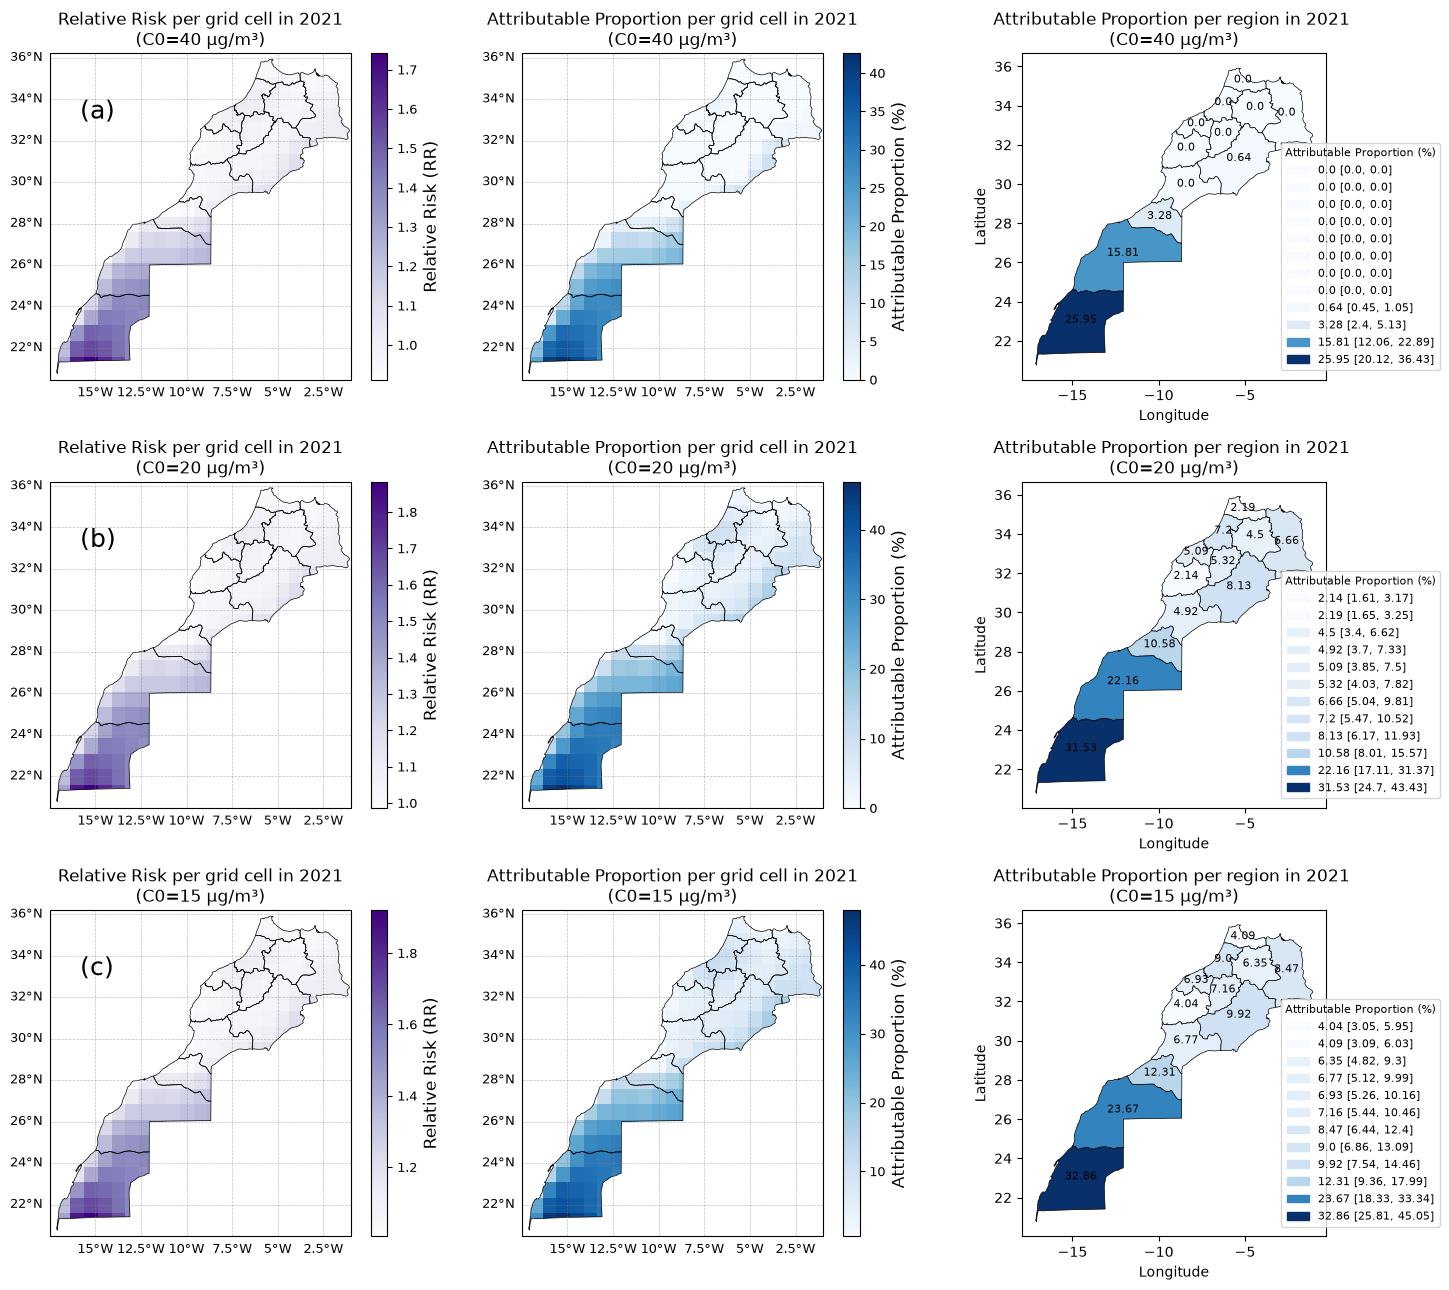

In [45]:
# Define the Albers Equal Area Conic projection parameters for the region
projection = ccrs.PlateCarree()

fig = plt.figure(figsize=(15, 13))
gs = fig.add_gridspec(nrows=3, ncols=3)

axs = [[None]*3 for _ in range(3)]
for i in range(3):
    axs[i][0] = fig.add_subplot(gs[i, 0], projection=projection)  # Cartopy GeoAxes
    axs[i][1] = fig.add_subplot(gs[i, 1], projection=projection)  # Cartopy GeoAxes
    axs[i][2] = fig.add_subplot(gs[i, 2])                          # plain Axes, no projection

    
# Define the common range for the color scale
vmin, vmax = None, None

# Define latitude and longitude
latitude = C_2021_cliped.latitude.values
longitude = C_2021_cliped.longitude.values

letters = ['(a)', '(b)', '(c)']
for i in range(3):
    
    ax = axs[i][0]
    c = Plot_Map_pcolormesh(data=RRs[i], latitude=latitude, longitude=longitude, projection=projection, Title=f'Relative Risk per grid cell in 2021\n(C0={Cs[i]} µg/m³)', fontsize_title=12, cmap="Purples", label = 'Relative Risk (RR)', ax=ax, vmin=vmin, vmax=vmax, shapefile=shapefile_mar_reg, coastlines=False, common_colorbar=False, colorbar_ticks_to_int=False)
    clip_artist_to_shape(c, ax, shapefile_mar_reg.geometry)
    ax.text(0.1, 0.8, letters[i], transform=ax.transAxes, fontsize=18)
    
    ax = axs[i][1]
    c = Plot_Map_pcolormesh(data=APs[i], latitude=latitude, longitude=longitude, projection=projection, Title=f'Attributable Proportion per grid cell in 2021\n(C0={Cs[i]} µg/m³)', cmap="Blues", label = 'Attributable Proportion (%)', ax=ax, vmin=vmin, vmax=vmax, shapefile=shapefile_mar_reg, coastlines=False, common_colorbar=False, colorbar_ticks_to_int=False)
    clip_artist_to_shape(c, ax, shapefile_mar_reg.geometry)

    ax = axs[i][2]
    shapefile_mar_reg_['category_colors'] = extract_colors(shapefile_mar_reg_, column=f'Attributable Proportion (C0={Cs[i]})', cmap='Blues')
    Plot_Shapefile_CategoricalData(shapefile_mar_reg_, column=f'Attributable Proportion (C0={Cs[i]})', cmap='Blues', title=f'Attributable Proportion per region in 2021 \n(C0={Cs[i]} µg/m³)', label="Attributable Proportion (%)", fontsize_title=12, categorical_column=True, align_colors_with_categories=True, add_txt_labels=True, txt_labels_round=2, ax=ax)


# Adjust subplot layout
plt.tight_layout()

# Show the map
plt.show() 

# Save the plot to a file (e.g., in PNG format)
fig.savefig('Figures_PM10/Figure 3.png', bbox_inches="tight", dpi=500)

### 13. Plot Attributable Mortality Cases

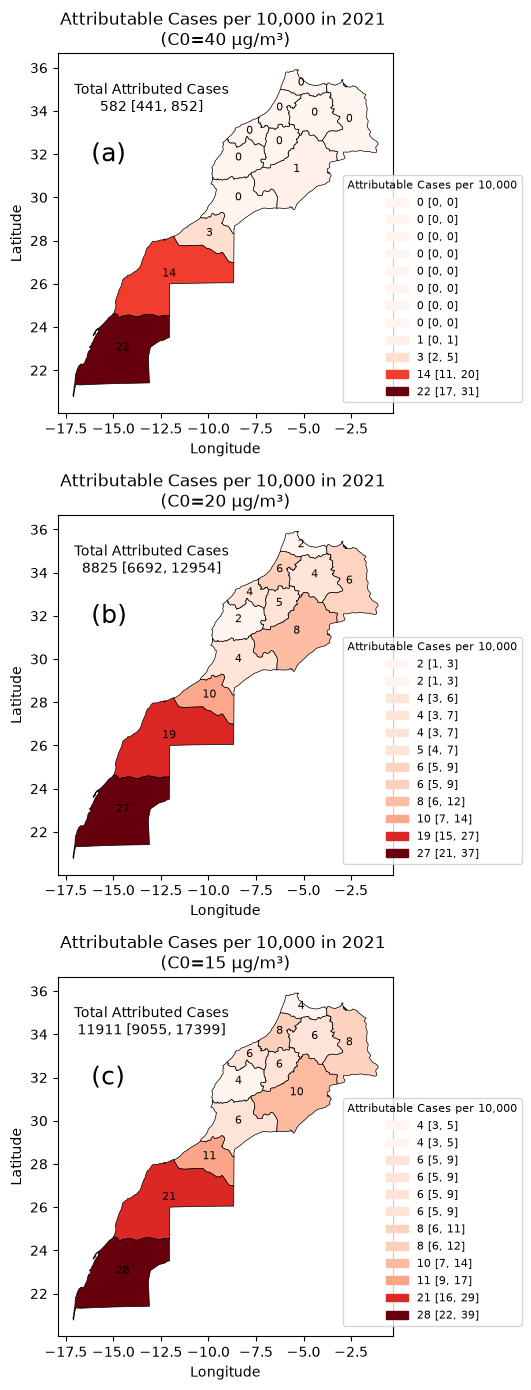

In [46]:
# Plot the map with customization
fig, axs = plt.subplots(3, 1, figsize=(10, 14))

letters = ['(a)', '(b)', '(c)']
for i in range(3):
    
    ax = axs[i]
    shapefile_mar_reg_['category_colors'] = extract_colors(shapefile_mar_reg_, column=f'Attributable Cases per 10,000 (C0={Cs[i]})', cmap='Reds')
    Plot_Shapefile_CategoricalData(shapefile_mar_reg_, column=f'Attributable Cases per 10,000 (C0={Cs[i]})', cmap='Reds', title=f'Attributable Cases per 10,000 in 2021 \n(C0={Cs[i]} µg/m³)', label="Attributable Cases per 10,000", categorical_column=True, align_colors_with_categories=True, add_txt_labels=True, txt_labels_round=None, ax=ax)
    ax.text(0.1, 0.7, letters[i], transform=ax.transAxes, fontsize=18)
    txt = "Total Attributed Cases\n"+f"{round(shapefile_mar_reg_[f'Attributable Cases (C0={Cs[i]})'].sum(),None)} [{round(shapefile_mar_reg_[f'Attributable Cases (C0={Cs[i]}) lower'].sum(),None)}, {round(shapefile_mar_reg_[f'Attributable Cases (C0={Cs[i]}) upper'].sum(),None)}]"
    ax.annotate(text=txt, xy=(-13, 34), fontsize=10, ha='center', color='black')  #  fontweight='bold'

# Adjust subplot layout
plt.tight_layout()

plt.show()

# Save the plot to a file (e.g., in PNG format)
fig.savefig('Figures_PM10/Figure 4.png', bbox_inches="tight", dpi=500)

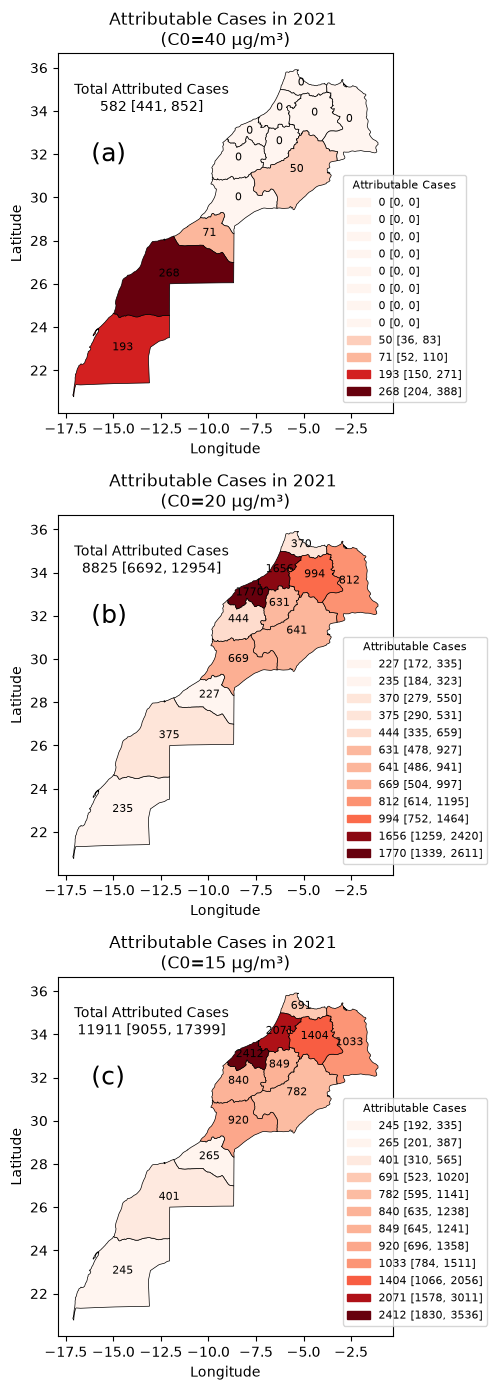

In [47]:
# Plot the map with customization
fig, axs = plt.subplots(3, 1, figsize=(10, 14))

letters = ['(a)', '(b)', '(c)']
for i in range(3):
    
    ax = axs[i]
    shapefile_mar_reg_['category_colors'] = extract_colors(shapefile_mar_reg_, column=f'Attributable Cases (C0={Cs[i]})', cmap='Reds')
    Plot_Shapefile_CategoricalData(shapefile_mar_reg_, column=f'Attributable Cases (C0={Cs[i]})', cmap='Reds', title=f'Attributable Cases in 2021 \n(C0={Cs[i]} µg/m³)', label="Attributable Cases", categorical_column=True, align_colors_with_categories=True, add_txt_labels=True, txt_labels_round=None, ax=ax)
    ax.text(0.1, 0.7, letters[i], transform=ax.transAxes, fontsize=18)
    txt = "Total Attributed Cases\n"+f"{round(shapefile_mar_reg_[f'Attributable Cases (C0={Cs[i]})'].sum(),None)} [{round(shapefile_mar_reg_[f'Attributable Cases (C0={Cs[i]}) lower'].sum(),None)}, {round(shapefile_mar_reg_[f'Attributable Cases (C0={Cs[i]}) upper'].sum(),None)}]"
    ax.annotate(text=txt, xy=(-13, 34), fontsize=10, ha='center', color='black')  #  fontweight='bold'

# Adjust subplot layout
plt.tight_layout()

plt.show()

# Save the plot to a file (e.g., in PNG format)
fig.savefig('Figures_PM10/Figure S3.png', bbox_inches="tight", dpi=500)